# Justificativa dos JOINs — carteira_flat
## Por que cada tabela foi incluída na visão consolidada?

Este notebook demonstra, com dados simulados, a necessidade de cada JOIN  
realizado pelo pipeline ETL para construir a visão `carteira_flat`.

A tabela central é `posicao_carteira` (tabela fato).  
Cada JOIN adiciona uma dimensão de negócio que sozinha não existiria na fato.

---

### Modelo de dados
```
EMISSOR ──< ATIVO ──< POSICAO_CARTEIRA >── FUNDO
                           │
                      PRECO_MERCADO
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import glob
import os

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['font.family']    = 'DejaVu Sans'

CORES = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

print('ok')

ok


In [2]:
arquivos = glob.glob('../output/**/part-*.csv', recursive=True)
arquivo  = max(arquivos, key=os.path.getmtime)

df = pd.read_csv(arquivo)
df['valor_financeiro'] = pd.to_numeric(df['valor_financeiro'], errors='coerce')
df['percentual_pl']    = pd.to_numeric(df['percentual_pl'],    errors='coerce')
df['preco_mercado']    = pd.to_numeric(df['preco_mercado'],    errors='coerce')
df['preco_unitario']   = pd.to_numeric(df['preco_unitario'],   errors='coerce')

print(f'carteira_flat carregada: {df.shape[0]} registros, {df.shape[1]} colunas')
df.head(3)

carteira_flat carregada: 18 registros, 19 colunas


,data_posicao,cnpj_fundo,nome_fundo,tipo_fundo,codigo_ativo,nome_ativo,classe_ativo,indexador,data_vencimento,nome_emissor,cnpj_emissor,setor_emissor,rating_emissor,quantidade,preco_unitario,preco_mercado,valor_financeiro,percentual_pl,fonte_preco
0,2024-05-31,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa,CDB-ITAU-2025,CDB Itau 120% CDI 2025,Renda Fixa,CDI,2025-12-01,Itau Unibanco Holding S.A.,60.872.504/0001-23,Financeiro,AA-,600.0,10245.60,10245.60,6147360.0,12.230,ANBIMA
1,2024-05-31,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa,LFT-2027,Tesouro Selic 2027,Renda Fixa,SELIC,2027-09-01,Tesouro Nacional,00.394.460/0001-41,NaN,AAA,200.0,12456.78,12456.78,2491356.0,4.958,ANBIMA
2,2024-05-31,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa,NTNB-2035,Tesouro IPCA+ 2035,Renda Fixa,IPCA,2035-05-15,Tesouro Nacional,00.394.460/0001-41,NaN,AAA,5000.0,3542.18,3542.18,17710900.0,35.250,ANBIMA


---
## JOIN 1 — posicao_carteira + fundo
### Pergunta: o que a posição sabe sobre o fundo sem o JOIN?

In [3]:
# Sem o JOIN com FUNDO, a posição só sabe o id_fundo
# Simulamos isso mostrando apenas as colunas que vêm da fato
colunas_fato = ['data_posicao', 'codigo_ativo', 'quantidade', 
                'preco_unitario', 'valor_financeiro', 'percentual_pl']

print('=== POSICAO_CARTEIRA sem JOIN com FUNDO ===')
print('O analista só enxerga isso:')
df[colunas_fato].head(5)

=== POSICAO_CARTEIRA sem JOIN com FUNDO ===
O analista só enxerga isso:


,data_posicao,codigo_ativo,quantidade,preco_unitario,valor_financeiro,percentual_pl
0,2024-05-31,CDB-ITAU-2025,600.0,10245.60,6147360.0,12.230
1,2024-05-31,LFT-2027,200.0,12456.78,2491356.0,4.958
2,2024-05-31,NTNB-2035,5000.0,3542.18,17710900.0,35.250
3,2024-05-31,NTNF-2031,8000.0,1089.54,8716320.0,17.340
4,2024-05-31,PETRDB-2028,15000.0,1023.45,15351750.0,30.550


In [4]:
print('=== APÓS JOIN com FUNDO — informações adicionadas ===')
colunas_apos_fundo = colunas_fato + ['cnpj_fundo', 'nome_fundo', 'tipo_fundo']
df[colunas_apos_fundo].head(5)

=== APÓS JOIN com FUNDO — informações adicionadas ===


,data_posicao,codigo_ativo,quantidade,preco_unitario,valor_financeiro,percentual_pl,cnpj_fundo,nome_fundo,tipo_fundo
0,2024-05-31,CDB-ITAU-2025,600.0,10245.60,6147360.0,12.230,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa
1,2024-05-31,LFT-2027,200.0,12456.78,2491356.0,4.958,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa
2,2024-05-31,NTNB-2035,5000.0,3542.18,17710900.0,35.250,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa
3,2024-05-31,NTNF-2031,8000.0,1089.54,8716320.0,17.340,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa
4,2024-05-31,PETRDB-2028,15000.0,1023.45,15351750.0,30.550,12.345.678/0001-90,Sicred RF Conservador FI,Renda Fixa


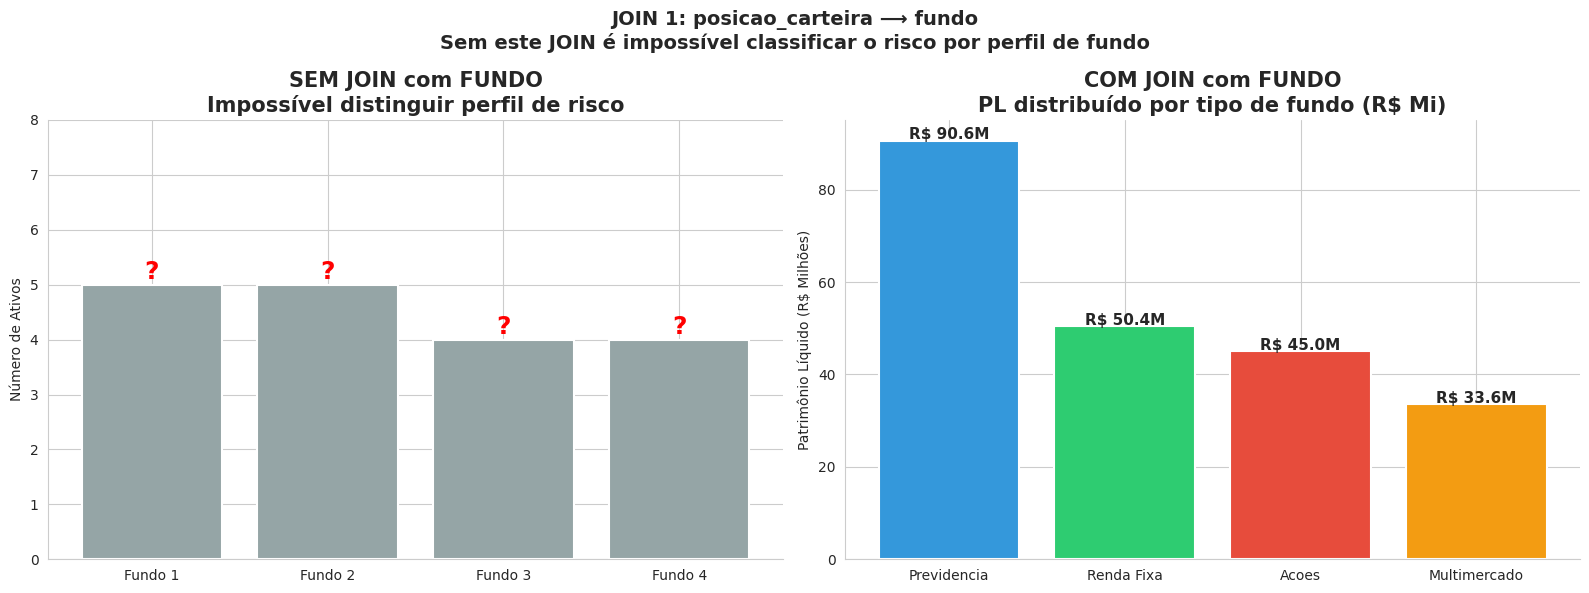

In [5]:
# Sem o JOIN com FUNDO não é possível saber o tipo de fundo
# Mostramos que o tipo_fundo muda completamente a interpretação do risco
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sem JOIN — tudo parece igual, sem contexto
ax = axes[0]
contagem_sem = pd.DataFrame({'fundo': [f'Fundo {i+1}' for i in range(4)],
                              'ativos': [5, 5, 4, 4]})
bars = ax.bar(contagem_sem['fundo'], contagem_sem['ativos'],
              color='#95a5a6', edgecolor='white', linewidth=1.5)
ax.set_title('SEM JOIN com FUNDO\nImpossível distinguir perfil de risco', fontweight='bold')
ax.set_ylabel('Número de Ativos')
ax.set_ylim(0, 8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            '?', ha='center', fontsize=18, color='red', fontweight='bold')
sns.despine(ax=ax)

# Com JOIN — cada fundo tem identidade clara
ax = axes[1]
pl_por_tipo = df.groupby('tipo_fundo')['valor_financeiro'].sum().sort_values(ascending=False)
bars2 = ax.bar(pl_por_tipo.index, pl_por_tipo.values / 1e6,
               color=CORES[:len(pl_por_tipo)], edgecolor='white', linewidth=1.5)
ax.set_title('COM JOIN com FUNDO\nPL distribuído por tipo de fundo (R$ Mi)', fontweight='bold')
ax.set_ylabel('Patrimônio Líquido (R$ Milhões)')
for bar, val in zip(bars2, pl_por_tipo.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'R$ {val/1e6:.1f}M', ha='center', fontweight='bold', fontsize=11)
sns.despine(ax=ax)

fig.suptitle('JOIN 1: posicao_carteira ⟶ fundo\nSem este JOIN é impossível classificar o risco por perfil de fundo',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## JOIN 2 — + ativo
### Pergunta: o que sabemos do ativo sem este JOIN?

In [6]:
print('=== SEM JOIN com ATIVO ===')
print('A posição só tem o código do ativo — sem classe, indexador ou vencimento:')
df[['codigo_ativo', 'valor_financeiro', 'percentual_pl']].head(5)

=== SEM JOIN com ATIVO ===
A posição só tem o código do ativo — sem classe, indexador ou vencimento:


,codigo_ativo,valor_financeiro,percentual_pl
0,CDB-ITAU-2025,6147360.0,12.230
1,LFT-2027,2491356.0,4.958
2,NTNB-2035,17710900.0,35.250
3,NTNF-2031,8716320.0,17.340
4,PETRDB-2028,15351750.0,30.550


In [7]:
print('=== APÓS JOIN com ATIVO ===')
print('Agora sabemos classe, indexador e vencimento:')
df[['codigo_ativo', 'nome_ativo', 'classe_ativo', 
    'indexador', 'data_vencimento', 'valor_financeiro']].head(10)

=== APÓS JOIN com ATIVO ===
Agora sabemos classe, indexador e vencimento:


,codigo_ativo,nome_ativo,classe_ativo,indexador,data_vencimento,valor_financeiro
0,CDB-ITAU-2025,CDB Itau 120% CDI 2025,Renda Fixa,CDI,2025-12-01,6147360.0
1,LFT-2027,Tesouro Selic 2027,Renda Fixa,SELIC,2027-09-01,2491356.0
2,NTNB-2035,Tesouro IPCA+ 2035,Renda Fixa,IPCA,2035-05-15,17710900.0
3,NTNF-2031,Tesouro Prefixado 2031,Renda Fixa,Prefixado,2031-01-01,8716320.0
4,PETRDB-2028,Debenture Petrobras 2028,Renda Fixa,CDI,2028-06-15,15351750.0
5,ITUB4,Itau Unibanco PN,Renda Variavel,NaN,INDEFINIDO,6436000.0
6,NTNB-2035,Tesouro IPCA+ 2035,Renda Fixa,IPCA,2035-05-15,10626540.0
7,PETR4,Petrobras PN,Renda Variavel,NaN,INDEFINIDO,4590000.0
8,VALE3,Vale ON,Renda Variavel,NaN,INDEFINIDO,5513600.0
9,WEGE3,WEG ON,Renda Variavel,NaN,INDEFINIDO,6400500.0


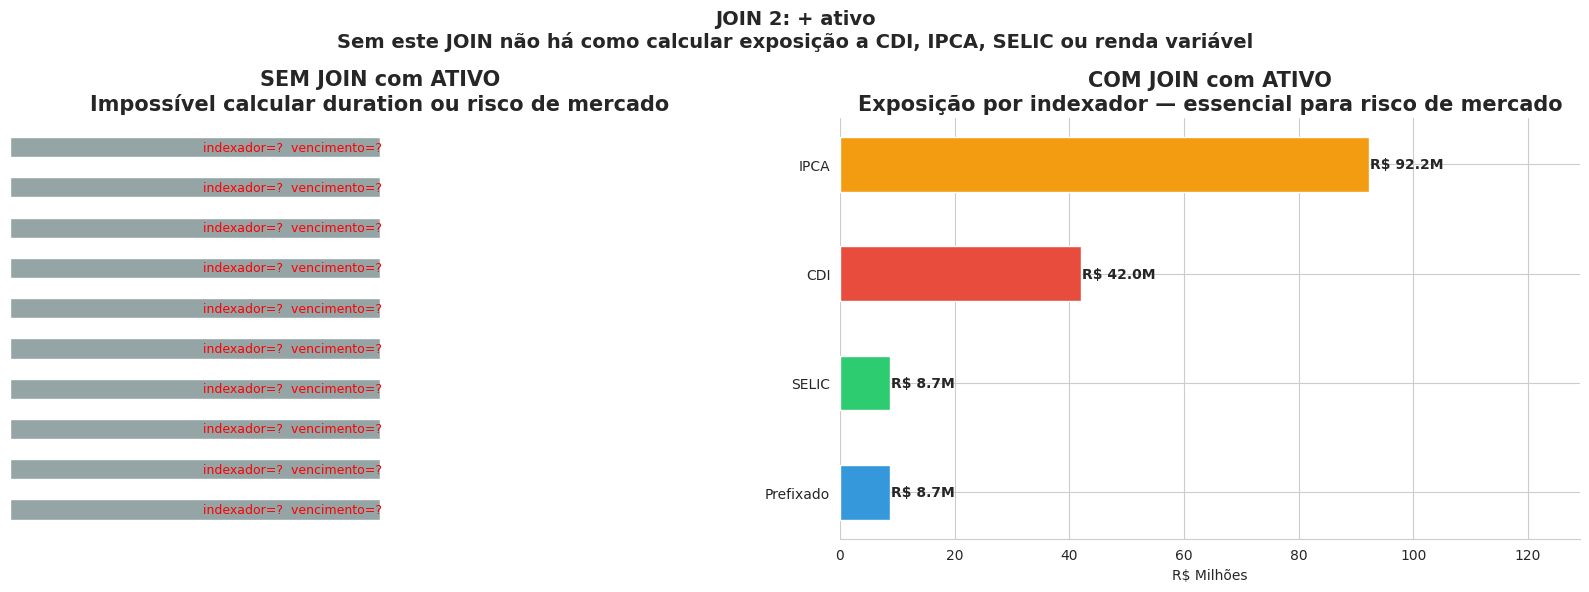

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sem JOIN — sem indexador, impossível calcular risco de mercado
ax = axes[0]
ativos = df['codigo_ativo'].unique()
ax.barh(ativos, [1]*len(ativos), color='#95a5a6', height=0.5)
for i, a in enumerate(ativos):
    ax.text(0.5, i, '  indexador=?  vencimento=?', va='center', fontsize=9, color='red')
ax.set_title('SEM JOIN com ATIVO\nImpossível calcular duration ou risco de mercado', fontweight='bold')
ax.set_xlim(0, 2)
ax.axis('off')

# Com JOIN — cada ativo tem sua classe e indexador
ax = axes[1]
expo_idx = df.groupby('indexador')['valor_financeiro'].sum().sort_values()
bars = ax.barh(expo_idx.index, expo_idx.values / 1e6,
               color=CORES[:len(expo_idx)], height=0.5, edgecolor='white')
for bar, val in zip(bars, expo_idx.values):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'R$ {val/1e6:.1f}M', va='center', fontweight='bold', fontsize=10)
ax.set_title('COM JOIN com ATIVO\nExposição por indexador — essencial para risco de mercado', fontweight='bold')
ax.set_xlabel('R$ Milhões')
ax.set_xlim(0, expo_idx.max()/1e6 * 1.4)
sns.despine(ax=ax, left=True)

fig.suptitle('JOIN 2: + ativo\nSem este JOIN não há como calcular exposição a CDI, IPCA, SELIC ou renda variável',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## JOIN 3 — + emissor
### Pergunta: por que precisamos saber quem emitiu o ativo?

In [9]:
print('=== SEM JOIN com EMISSOR ===')
print('Sabemos o ativo mas não sabemos quem o emitiu — sem rating, sem setor:')
df[['codigo_ativo', 'classe_ativo', 'valor_financeiro']].drop_duplicates('codigo_ativo').head(5)

=== SEM JOIN com EMISSOR ===
Sabemos o ativo mas não sabemos quem o emitiu — sem rating, sem setor:


,codigo_ativo,classe_ativo,valor_financeiro
0,CDB-ITAU-2025,Renda Fixa,6147360.0
1,LFT-2027,Renda Fixa,2491356.0
2,NTNB-2035,Renda Fixa,17710900.0
3,NTNF-2031,Renda Fixa,8716320.0
4,PETRDB-2028,Renda Fixa,15351750.0


In [10]:
print('=== APÓS JOIN com EMISSOR ===')
print('Agora temos rating de crédito e setor econômico:')
df[['codigo_ativo', 'nome_emissor', 'cnpj_emissor', 
    'setor_emissor', 'rating_emissor', 'valor_financeiro']].drop_duplicates('codigo_ativo')

=== APÓS JOIN com EMISSOR ===
Agora temos rating de crédito e setor econômico:


,codigo_ativo,nome_emissor,cnpj_emissor,setor_emissor,rating_emissor,valor_financeiro
0,CDB-ITAU-2025,Itau Unibanco Holding S.A.,60.872.504/0001-23,Financeiro,AA-,6147360.0
1,LFT-2027,Tesouro Nacional,00.394.460/0001-41,NaN,AAA,2491356.0
2,NTNB-2035,Tesouro Nacional,00.394.460/0001-41,NaN,AAA,17710900.0
3,NTNF-2031,Tesouro Nacional,00.394.460/0001-41,NaN,AAA,8716320.0
4,PETRDB-2028,Petroleo Brasileiro S.A. - Petrobras,33.000.167/0001-01,Energia,BBB+,15351750.0
5,ITUB4,Itau Unibanco Holding S.A.,60.872.504/0001-23,Financeiro,AA-,6436000.0
7,PETR4,Petroleo Brasileiro S.A. - Petrobras,33.000.167/0001-01,Energia,BBB+,4590000.0
8,VALE3,Vale S.A.,33.592.510/0001-54,Mineracao,BBB+,5513600.0
9,WEGE3,WEG S.A.,84.429.695/0001-11,Industrial,A+,6400500.0
15,LCI-BRAD-2026,Banco Bradesco S.A.,60.746.948/0001-12,Financeiro,AA-,28429240.0


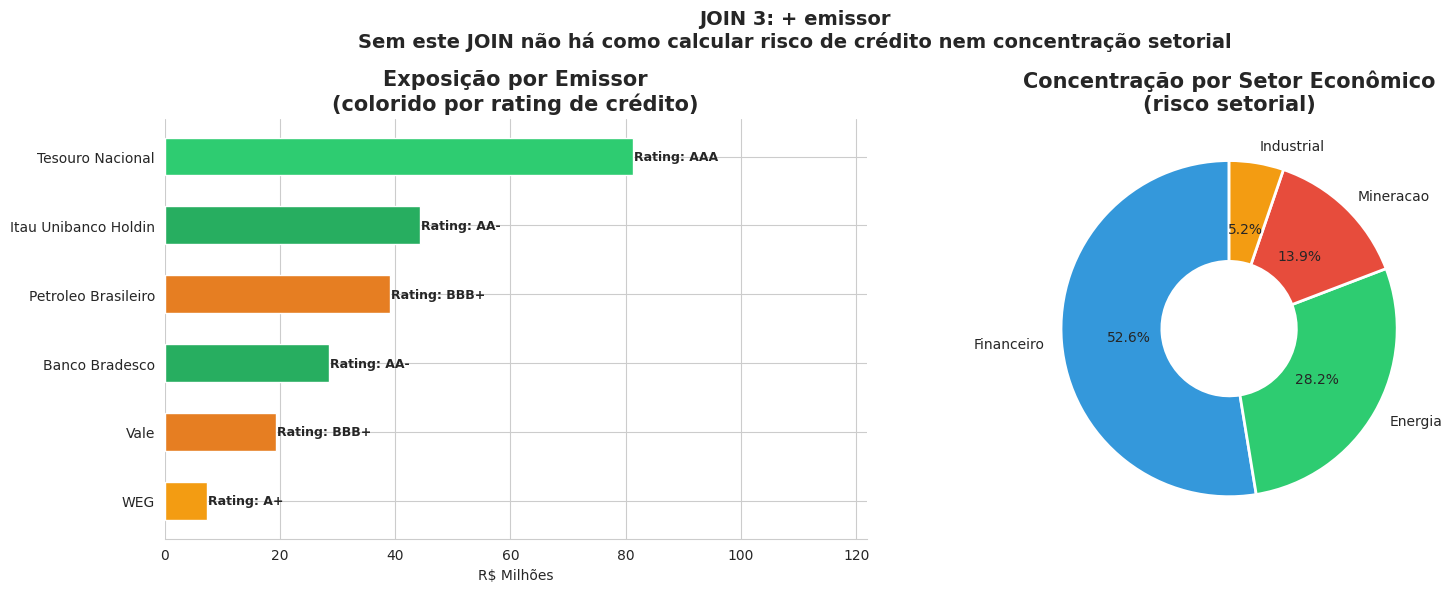

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Concentração por emissor — risco de crédito
ax = axes[0]
por_emissor = df.groupby(['nome_emissor', 'rating_emissor'])['valor_financeiro'].sum().reset_index()
por_emissor = por_emissor.sort_values('valor_financeiro', ascending=True)
nomes = [n.split(' S.A.')[0][:20] for n in por_emissor['nome_emissor']]
cores_rat = ['#2ecc71' if r == 'AAA' else '#27ae60' if r in ['AA-','AA+']
             else '#f39c12' if r == 'A+' else '#e67e22'
             for r in por_emissor['rating_emissor']]

bars = ax.barh(nomes, por_emissor['valor_financeiro']/1e6,
               color=cores_rat, height=0.55, edgecolor='white')
for bar, row in zip(bars, por_emissor.itertuples()):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'Rating: {row.rating_emissor}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Exposição por Emissor\n(colorido por rating de crédito)', fontweight='bold')
ax.set_xlabel('R$ Milhões')
ax.set_xlim(0, por_emissor['valor_financeiro'].max()/1e6 * 1.5)
sns.despine(ax=ax, left=True)

# Concentração por setor
ax = axes[1]
por_setor = df.groupby('setor_emissor')['valor_financeiro'].sum().sort_values(ascending=False)
ax.pie(por_setor.values, labels=por_setor.index, autopct='%1.1f%%',
       colors=CORES[:len(por_setor)], startangle=90,
       wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2))
ax.set_title('Concentração por Setor Econômico\n(risco setorial)', fontweight='bold')

fig.suptitle('JOIN 3: + emissor\nSem este JOIN não há como calcular risco de crédito nem concentração setorial',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## JOIN 4 — + preco_mercado
### Pergunta: por que não usar o preco_unitario da posição diretamente?

In [12]:
print('=== DIFERENÇA ENTRE preco_unitario E preco_mercado ===\n')

comparativo = df[['codigo_ativo', 'nome_ativo', 'classe_ativo',
                  'preco_unitario', 'preco_mercado', 'fonte_preco']].drop_duplicates('codigo_ativo').copy()

comparativo['preco_unitario'] = pd.to_numeric(comparativo['preco_unitario'], errors='coerce')
comparativo['preco_mercado']  = pd.to_numeric(comparativo['preco_mercado'],  errors='coerce')
comparativo['diferenca_pct']  = ((comparativo['preco_mercado'] - comparativo['preco_unitario'])
                                  / comparativo['preco_unitario'] * 100).round(4)

print('preco_unitario = preço na data de aquisição / custódia')
print('preco_mercado  = preço de fechamento do mercado na data de referência (MTM)')
print()
comparativo[['codigo_ativo', 'classe_ativo', 'preco_unitario', 
             'preco_mercado', 'diferenca_pct', 'fonte_preco']]

=== DIFERENÇA ENTRE preco_unitario E preco_mercado ===

preco_unitario = preço na data de aquisição / custódia
preco_mercado  = preço de fechamento do mercado na data de referência (MTM)



,codigo_ativo,classe_ativo,preco_unitario,preco_mercado,diferenca_pct,fonte_preco
0,CDB-ITAU-2025,Renda Fixa,10245.60,10245.60,0.0,ANBIMA
1,LFT-2027,Renda Fixa,12456.78,12456.78,0.0,ANBIMA
2,NTNB-2035,Renda Fixa,3542.18,3542.18,0.0,ANBIMA
3,NTNF-2031,Renda Fixa,1089.54,1089.54,0.0,ANBIMA
4,PETRDB-2028,Renda Fixa,1023.45,1023.45,0.0,ANBIMA
5,ITUB4,Renda Variavel,32.18,32.18,0.0,B3
7,PETR4,Renda Variavel,38.25,38.25,0.0,B3
8,VALE3,Renda Variavel,68.92,68.92,0.0,B3
9,WEGE3,Renda Variavel,42.67,42.67,0.0,B3
15,LCI-BRAD-2026,Renda Fixa,1015.33,1015.33,0.0,ANBIMA


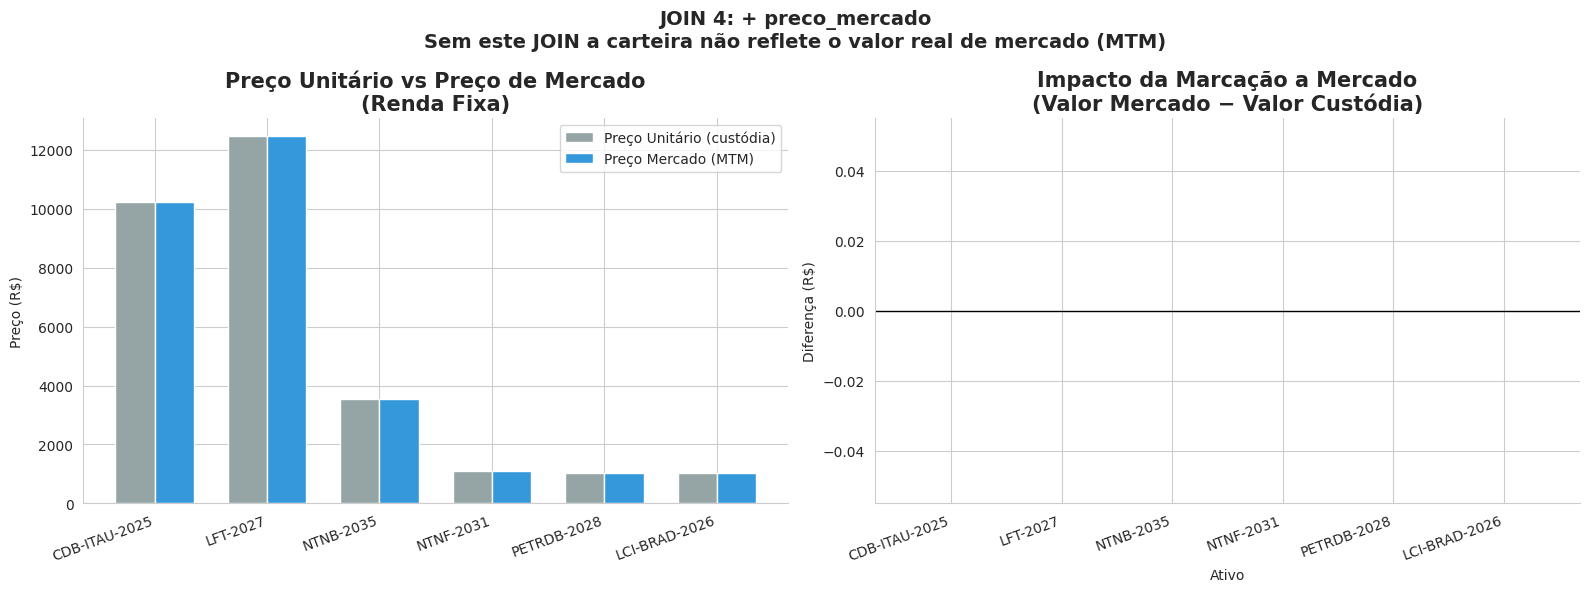

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

comparativo_rf = comparativo[comparativo['classe_ativo'] == 'Renda Fixa'].dropna()

# Comparação preço unitário vs mercado
ax = axes[0]
x = range(len(comparativo_rf))
width = 0.35
bars1 = ax.bar([i - width/2 for i in x], comparativo_rf['preco_unitario'],
               width=width, label='Preço Unitário (custódia)', color='#95a5a6', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], comparativo_rf['preco_mercado'],
               width=width, label='Preço Mercado (MTM)', color='#3498db', edgecolor='white')
ax.set_xticks(list(x))
ax.set_xticklabels(comparativo_rf['codigo_ativo'], rotation=20, ha='right')
ax.set_title('Preço Unitário vs Preço de Mercado\n(Renda Fixa)', fontweight='bold')
ax.set_ylabel('Preço (R$)')
ax.legend(fontsize=10)
sns.despine(ax=ax)

# Diferença percentual — impacto no valor financeiro
ax = axes[1]
df_impacto = df[df['classe_ativo'] == 'Renda Fixa'].copy()
df_impacto['preco_unitario']  = pd.to_numeric(df_impacto['preco_unitario'],  errors='coerce')
df_impacto['preco_mercado']   = pd.to_numeric(df_impacto['preco_mercado'],   errors='coerce')
df_impacto['quantidade']      = pd.to_numeric(df_impacto['quantidade'],       errors='coerce')
df_impacto['valor_custódia']  = df_impacto['quantidade'] * df_impacto['preco_unitario']
df_impacto['valor_mercado']   = df_impacto['quantidade'] * df_impacto['preco_mercado']
df_impacto['diferenca_valor'] = df_impacto['valor_mercado'] - df_impacto['valor_custódia']

cores_dif = ['#2ecc71' if v >= 0 else '#e74c3c' for v in df_impacto['diferenca_valor']]
bars = ax.bar(df_impacto['codigo_ativo'], df_impacto['diferenca_valor'],
              color=cores_dif, edgecolor='white')
ax.axhline(y=0, color='black', linewidth=1)
ax.set_title('Impacto da Marcação a Mercado\n(Valor Mercado − Valor Custódia)', fontweight='bold')
ax.set_ylabel('Diferença (R$)')
ax.set_xlabel('Ativo')
plt.xticks(rotation=20, ha='right')
sns.despine(ax=ax)

fig.suptitle('JOIN 4: + preco_mercado\nSem este JOIN a carteira não reflete o valor real de mercado (MTM)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Resumo — Por que cada JOIN é indispensável

In [14]:
resumo = pd.DataFrame({
    'JOIN': [
        'posicao_carteira + fundo',
        'posicao_carteira + ativo',
        'ativo + emissor',
        'posicao_carteira + preco_mercado'
    ],
    'Chave': [
        'id_fundo',
        'id_ativo',
        'id_emissor',
        'data_posicao + id_ativo'
    ],
    'Tipo': ['LEFT', 'LEFT', 'LEFT', 'LEFT'],
    'Colunas adicionadas': [
        'cnpj_fundo, nome_fundo, tipo_fundo',
        'codigo_ativo, nome_ativo, classe_ativo, indexador, data_vencimento',
        'nome_emissor, cnpj_emissor, setor_emissor, rating_emissor',
        'preco_mercado, fonte_preco'
    ],
    'Sem este JOIN não é possível': [
        'Classificar risco por perfil de fundo',
        'Calcular exposição por indexador ou duration',
        'Calcular risco de crédito ou concentração setorial',
        'Marcar a carteira a mercado (MTM)'
    ]
})

resumo

,JOIN,Chave,Tipo,Colunas adicionadas,Sem este JOIN não é possível
0,posicao_carteira + fundo,id_fundo,LEFT,"cnpj_fundo, nome_fundo, tipo_fundo",Classificar risco por perfil de fundo
1,posicao_carteira + ativo,id_ativo,LEFT,"codigo_ativo, nome_ativo, classe_ativo, indexa...",Calcular exposição por indexador ou duration
2,ativo + emissor,id_emissor,LEFT,"nome_emissor, cnpj_emissor, setor_emissor, rat...",Calcular risco de crédito ou concentração seto...
3,posicao_carteira + preco_mercado,data_posicao + id_ativo,LEFT,"preco_mercado, fonte_preco",Marcar a carteira a mercado (MTM)


---
## Por que todos os JOINs são LEFT e não INNER?

Com **INNER JOIN**, um registro da `posicao_carteira` seria descartado silenciosamente se:
- O ativo não tivesse preço de mercado cadastrado para aquela data
- O emissor tivesse sido removido da base de referência
- O fundo estivesse com cadastro incompleto

Em **Asset Management**, perder uma posição silenciosamente é crítico:
- O PL calculado ficaria menor do que o real
- Relatórios de risco estariam incompletos
- A reconciliação com a custódia falharia

Com **LEFT JOIN**, a posição sempre aparece no output.  
Campos sem correspondência recebem `N/A` — o problema fica visível e auditável.

---
## Conclusão

Cada JOIN da `carteira_flat` resolve um problema real de negócio:

| JOIN | Problema resolvido |
|------|-------------------|
| `+ fundo` | Sem ele, não há perfil de risco nem classificação do fundo |
| `+ ativo` | Sem ele, não há indexador, classe nem vencimento para análise de risco de mercado |
| `+ emissor` | Sem ele, não há rating de crédito nem setor para análise de concentração |
| `+ preco_mercado` | Sem ele, a carteira não está marcada a mercado — o PL reportado seria incorreto |

O uso de **LEFT JOIN** em todos os casos garante que nenhuma posição seja perdida,  
mesmo que dados de referência estejam incompletos — princípio fundamental de integridade em Asset Management.